In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


The force_remount=True ensures a fresh mount every time, preventing stale access issues.

In [3]:
# Install PyTorch for CUDA 12.6 (you already have this, but reinstalling doesn't hurt to align versions)
!pip install torch==2.8.0 torchvision==0.15.1 torchaudio==2.8.0 --extra-index-url https://download.pytorch.org/whl/cu126

# Install torch_geometric dependencies for torch 2.8.0 and cu126
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

# Finally install torch_geometric itself
!pip install torch-geometric


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu126
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.15.1 (from versions: 0.1.6, 0.2.0, 0.17.0, 0.17.1, 0.17.2, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.20.0, 0.20.1, 0.21.0, 0.21.0+cu126, 0.22.0, 0.22.0+cu126, 0.22.1, 0.22.1+cu126, 0.23.0, 0.23.0+cu126, 0.24.0, 0.24.0+cu126, 0.24.1, 0.24.1+cu126)
ERROR: No matching distribution found for torchvision==0.15.1
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 129.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 53.1 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 20

In [4]:
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data


In [5]:
#Load individual pedestrian trajectories and all positions per frame.
#- 'trajectories': Each entry is a person's movement history (track) across frames.
#- 'frame_to_positions': Dictionary mapping frame numbers to detected positions in that frame.
import pickle
with open('/content/drive/MyDrive/Store/trajectories.pkl', 'rb') as f: trajectories = pickle.load(f)

with open('/content/drive/MyDrive/Store/frame_to_positions.pkl', 'rb') as f: frame_to_positions = pickle.load(f)

print(f"Loaded {len(trajectories)} trajectories and {len(frame_to_positions)} frames of positions.")

Loaded 3876 trajectories and 2096 frames of positions.


In [ ]:
# For every pedestrian track, slides a time window and extracts behavioral & contextual features per window.
# Features include: local crowd density, neighbor interaction, direction/speed patterns, and movement scatter.

import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import pandas as pd, numpy as np, time
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from sklearn.neighbors import BallTree
import pickle

# === BEHAVIORAL FEATURE EXTRACTION ===
def extract_behavioral_features(trajectories, frame_to_positions, window=30, stride=10, radius=50):
    features = []
    for track_id, traj in trajectories.items():
        if len(traj) < window:
            continue
        for i in range(0, len(traj)-window+1, stride):
            window_frames = traj[i:i+window]
            # --- Correct unpacking for your data ---
            centers = [ ((entry['bbox'][0]+entry['bbox'][2])/2, (entry['bbox'][1]+entry['bbox'][3])/2)
                       for entry in window_frames ]
            frames = [entry['frame'] for entry in window_frames]

            densities = []
            interactions = []
            for fno, c in zip(frames, centers):
                # This line below ensures we use fid and bbox structure from frame_to_positions
                neigh = [
                    n for tid, n in frame_to_positions.get(fno, [])
                    if tid != track_id and np.linalg.norm(np.array(c)-np.array([(n[0]+n[2])/2, (n[1]+n[3])/2])) < radius
                ]
                densities.append(len(neigh))
                if neigh:
                    interactions.append(np.mean([
                        np.linalg.norm(np.array(c)-np.array([(n[0]+n[2])/2, (n[1]+n[3])/2])) for n in neigh
                    ]))

            avg_density = np.mean(densities) if densities else 0
            interaction_count = np.mean(interactions) if interactions else 0

            # Direction, speed, scatter
            center_array = np.array(centers)
            dir_var = np.var(np.diff(np.arctan2(center_array[:,1], center_array[:,0]))) if len(center_array)>1 else 0
            speeds = np.linalg.norm(np.diff(center_array, axis=0), axis=1)
            avg_speed = np.mean(speeds) if len(speeds)>0 else 0
            std_speed = np.std(speeds)
            scatter = np.linalg.norm(center_array[-1] - center_array[0])

            features.append({
                'track_id': track_id,
                'start_frame': frames[0],
                'end_frame': frames[-1],
                'avg_density': avg_density,
                'interaction_count': interaction_count,
                'direction_variance': dir_var,
                'avg_speed': avg_speed,
                'std_speed': std_speed,
                'scatter': scatter
            })
    df = pd.DataFrame(features)
    df.to_csv('/content/drive/MyDrive/Store/behavior_features.csv', index=False)
    print("Feature extraction done:", len(df))
    return df


df_features = extract_behavioral_features(trajectories, frame_to_positions)

In [6]:
import pandas as pd, numpy as np
df_features = pd.read_csv('/content/drive/MyDrive/Store/behavior_features.csv')
print(df_features.columns)
print(df_features.head())


Index(['track_id', 'start_frame', 'end_frame', 'avg_density',
       'interaction_count', 'direction_variance', 'avg_speed', 'std_speed',
       'scatter'],
      dtype='object')
   track_id  start_frame  end_frame  avg_density  interaction_count  \
0         1            1          8     1.300000          25.895815   
1         1            3         10     1.466667          28.712327   
2         1            6         13     1.666667          32.759863   
3         1            8         15     1.500000          33.075092   
4         1           11         18     1.433333          34.278807   

   direction_variance    avg_speed   std_speed      scatter  
0            0.234507  1186.392122  322.479348  1672.265872  
1            0.209676  1158.342124  317.899179   820.541450  
2            0.201399  1193.678804  319.800276  1672.527699  
3            0.160595  1166.926382  309.297598   798.992735  
4            0.139121  1176.227245  298.459176   541.600973  


In [7]:
def get_risk(row):
    return 1 if (
        row['avg_density'] > 2.6 or            # higher, more selective
        row['interaction_count'] > 40 or       # higher, more selective
        row['direction_variance'] > 0.13 or    # higher, more selective
        row['avg_speed'] > 20 or               # higher than before
        row['std_speed'] > 26 or               # higher than before
        row['scatter'] > 180                   # higher than before
    ) else 0
df_features['risk_flag'] = df_features.apply(get_risk, axis=1)
print(df_features['risk_flag'].value_counts())


risk_flag
1    38418
0    21497
Name: count, dtype: int64


In [8]:

def get_risk(row):
    return 1 if (
        row['avg_density'] >4 or            # higher, more selective
        row['interaction_count'] > 30 or       # higher, more selective
        row['direction_variance'] > 0.3 or    # higher, more selective
        row['avg_speed'] > 28 or               # higher than before
        row['std_speed'] > 26 or               # higher than before
        row['scatter'] > 200                   # higher than before
    ) else 0
df_features['risk_flag'] = df_features.apply(get_risk, axis=1)
print(df_features['risk_flag'].value_counts())


risk_flag
1    51331
0     8584
Name: count, dtype: int64


In [9]:
track_to_seq = {}
for tid, traj in trajectories.items():
    if len(traj) == 0:
        continue
    # all points of a track have the same sequence
    sequence = traj[0]['sequence']
    track_to_seq[tid] = sequence

# Step 2: Map the sequence info into your DataFrame
df_features['sequence'] = df_features['track_id'].map(track_to_seq)

# Step 3: Check if any rows are missing sequence info
missing_seq_count = df_features['sequence'].isnull().sum()
print(f"Rows with missing sequence info: {missing_seq_count}")

Rows with missing sequence info: 0


In [10]:
#Organize by Sequence and Prepare for Model Training:Sort data into training and test sets based on video scene, so we can evaluate model performance honestly
# Step 2: Now split
train_seqs = ['MOT20-01', 'MOT20-02', 'MOT20-03']
val_seqs = ['MOT20-05']
df_train = df_features[df_features['sequence'].isin(train_seqs)].reset_index(drop=True)
df_val = df_features[df_features['sequence'].isin(val_seqs)].reset_index(drop=True)

# Step 3: Now this works
y_train = df_train['risk_flag'].values
y_val = df_val['risk_flag'].values


In [11]:
#For each feature window (row in your DataFrame), find all the bounding boxes for that pedestrian during the window's frame range, and assign their average/mean bounding box.
#This gives a typical location and size for each person's window, which helps in further graph construction and spatial analyses.
import numpy as np

def assign_bbox_to_window(df, trajectories):
    bboxes = []
    for idx, row in df.iterrows():
        track_id = row['track_id']
        start_frame = int(row['start_frame'])
        end_frame = int(row['end_frame'])
        traj = trajectories.get(track_id, [])
        # Get bboxes within window frames
        bboxes_in_window = [p['bbox'] for p in traj if start_frame <= p['frame'] <= end_frame]
        if not bboxes_in_window:
            bboxes.append([np.nan, np.nan, np.nan, np.nan])  # Mark missing
            continue
        # Calculate mean bbox
        arr = np.array(bboxes_in_window)
        mean_bbox = arr.mean(axis=0)
        bboxes.append(mean_bbox.tolist())
    return bboxes


In [12]:
#: Adds each window's mean bounding box location to the DataFrame. Then, removes windows where we couldn't find any bounding box (keeps data good for spatial work).
df_train['bbox'] = assign_bbox_to_window(df_train, trajectories)
df_val['bbox'] = assign_bbox_to_window(df_val, trajectories)
df_train = df_train[df_train['bbox'].apply(lambda b: isinstance(b, list) and not any(np.isnan(b)))]
df_val = df_val[df_val['bbox'].apply(lambda b: isinstance(b, list) and not any(np.isnan(b)))]


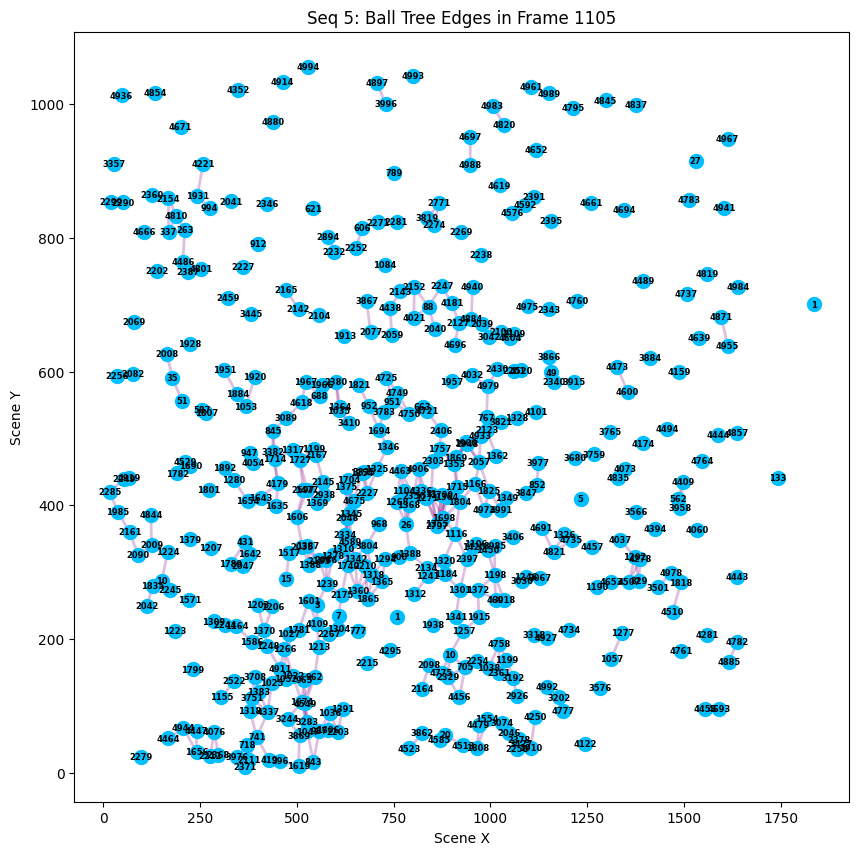

In [14]:
import random
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
import numpy as np

# 1. Pick a random row from seq 5 validation windows
seq5_rows = df_val[df_val['sequence'] == "MOT20-05"]
if len(seq5_rows) == 0:
    raise ValueError("No windows found for MOT20-05!")
chosen_row = seq5_rows.sample(1).iloc[0]
frame_no = int((chosen_row['start_frame'] + chosen_row['end_frame']) // 2)

# 2. Get all (track_id, bbox) in this frame
frame_positions = frame_to_positions.get(frame_no, [])  # list of (track_id, bbox)
if len(frame_positions) == 0:
    raise ValueError(f"No detections in frame {frame_no}!")

labels = []
centers = []
for tid, bbox in frame_positions:
    center = ((bbox[0]+bbox[2])/2, (bbox[1]+bbox[3])/2)
    centers.append(center)
    labels.append(tid)

X = np.array(centers)
radius = 50
tree = BallTree(X, leaf_size=40)
neighbors = tree.query_radius(X, r=radius)
plt.figure(figsize=(10, 10))
# Draw edges *first* for all pairs (makes lines visible under points)
for i, c in enumerate(centers):
    for j in neighbors[i]:
        if i < j: # avoid duplicate lines
            c2 = centers[j]
            plt.plot([c[0], c2[0]], [c[1], c2[1]], color='purple', alpha=0.25, linewidth=2, zorder=1)
# Draw nodes on top
for i, c in enumerate(centers):
    plt.scatter(*c, color='deepskyblue', s=100, zorder=2)
    plt.text(*c, str(labels[i]), color='black', fontsize=6, ha='center', va='center', weight='bold', zorder=3)
plt.title(f"Seq 5: Ball Tree Edges in Frame {frame_no}")
plt.xlabel("Scene X")
plt.ylabel("Scene Y")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
feature_cols = [
    'avg_density',
    'interaction_count',
    'direction_variance',
    'avg_speed',
    'std_speed',
    'scatter'
]
#Standardize features and build a crowd relationship graph so the neural network learns from both personal and neighbor behavior
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feature_cols])
X_val = scaler.transform(df_val[feature_cols])

In [ ]:
# For every analyzed pedestrian window, we find nearby windows and connect them—so the neural network "sees" which people are close enough to affect each other's risk.
from sklearn.neighbors import BallTree
import torch

def build_edge_index(df, radius=50):
    centers = [((b[0]+b[2])/2, (b[1]+b[3])/2)
               if isinstance(b, list) and len(b)==4 else (0,0)
               for b in df['bbox']]
    X = np.array(centers)
    tree = BallTree(X, leaf_size=40)
    neighbors = tree.query_radius(X, r=radius)
    edge_sources, edge_targets = [], []
    for i, nbrs in enumerate(neighbors):
        for j in nbrs:
            if i != j: edge_sources.append(i); edge_targets.append(j)
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    return edge_index

edge_index_train = build_edge_index(df_train, radius=50)
edge_index_val = build_edge_index(df_val, radius=50)


In [ ]:
#We pack all prepared crowd feature data (behavior, locations, labels, and edges showing interactions)
#into the format required for training our graph neural network—one package each for training and validation/testing.
from torch_geometric.data import Data
data_train = Data(
    x=torch.tensor(X_train, dtype=torch.float),
    edge_index=edge_index_train,
    y=torch.tensor(y_train, dtype=torch.long)
)

data_val = Data(
    x=torch.tensor(X_val, dtype=torch.float),
    edge_index=edge_index_val,
    y=torch.tensor(y_val, dtype=torch.long)
)


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class BehaviorGCN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=32):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, 2)  # binary output: risk/no risk

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model = BehaviorGCN(data_train.x.size(1), hidden_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    out = model(data_train.x.to(device), data_train.edge_index.to(device))

    loss = F.cross_entropy(out, data_train.y.to(device))

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_out = model(data_val.x.to(device), data_val.edge_index.to(device))
        val_pred = val_out.argmax(dim=1)
        val_acc = (val_pred == data_val.y.to(device)).sum().item() / len(data_val.y)
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Val Accuracy: {val_acc:.4f}")


Epoch 1, Loss: 0.6779, Val Accuracy: 0.6697
Epoch 2, Loss: 0.6265, Val Accuracy: 0.8432
Epoch 3, Loss: 0.5809, Val Accuracy: 0.8527
Epoch 4, Loss: 0.5405, Val Accuracy: 0.8396
Epoch 5, Loss: 0.5052, Val Accuracy: 0.8384
Epoch 6, Loss: 0.4744, Val Accuracy: 0.8384
Epoch 7, Loss: 0.4481, Val Accuracy: 0.8384
Epoch 8, Loss: 0.4259, Val Accuracy: 0.8384
Epoch 9, Loss: 0.4075, Val Accuracy: 0.8384
Epoch 10, Loss: 0.3927, Val Accuracy: 0.8384
Epoch 11, Loss: 0.3809, Val Accuracy: 0.8384
Epoch 12, Loss: 0.3720, Val Accuracy: 0.8384
Epoch 13, Loss: 0.3653, Val Accuracy: 0.8384
Epoch 14, Loss: 0.3604, Val Accuracy: 0.8384
Epoch 15, Loss: 0.3569, Val Accuracy: 0.8384
Epoch 16, Loss: 0.3544, Val Accuracy: 0.8384
Epoch 17, Loss: 0.3524, Val Accuracy: 0.8384
Epoch 18, Loss: 0.3508, Val Accuracy: 0.8451
Epoch 19, Loss: 0.3494, Val Accuracy: 0.8454
Epoch 20, Loss: 0.3482, Val Accuracy: 0.8484


In [ ]:
# Predict on validation, trigger alerts for risk cases
model.eval()
with torch.no_grad():
    logits = model(data_val.x.to(device), data_val.edge_index.to(device))
    pred = logits.argmax(dim=1).cpu().numpy()

df_val['pred_flag'] = pred
# Where pred_flag == 1, issue alert (these are risk windows)
alerts = df_val[df_val['pred_flag'] == 1]
# Optionally, save alerts with locations
alerts[['track_id', 'start_frame', 'end_frame', 'bbox', 'sequence']].to_csv('layer3_alert_output.csv', index=False)
print("Alert windows saved!")


Alert windows saved!


In [ ]:
model.eval()
with torch.no_grad():
    logits = model(data_val.x.to(device), data_val.edge_index.to(device))
    pred = logits.argmax(dim=1).cpu().numpy()

df_val['pred_flag'] = pred
# Save results for all windows (risk and no-risk) with relevant columns
output_path = '/content/drive/MyDrive/layer3_full_output.csv'
df_val[['track_id', 'start_frame', 'end_frame', 'bbox', 'sequence', 'pred_flag']].to_csv(output_path, index=False)
print(f"All prediction windows saved to: {output_path}")

All prediction windows saved to: /content/drive/MyDrive/layer3_full_output.csv


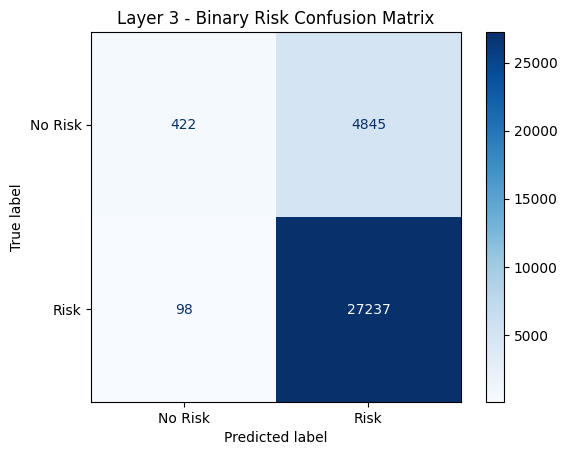

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(data_val.y.cpu(), pred, display_labels=['No Risk', 'Risk'], cmap='Blues')
plt.title('Layer 3 - Binary Risk Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# If you used Data objects as shown earlier:
y_true = data_val.y.cpu().numpy()  # Ground truth (No Risk=0, Risk=1)
y_pred = val_pred.cpu().numpy()    # Model predictions from validation

print(classification_report(y_true, y_pred, target_names=['No Risk', 'Risk']))

              precision    recall  f1-score   support

     No Risk       0.81      0.08      0.15      5267
        Risk       0.85      1.00      0.92     27335

    accuracy                           0.85     32602
   macro avg       0.83      0.54      0.53     32602
weighted avg       0.84      0.85      0.79     32602



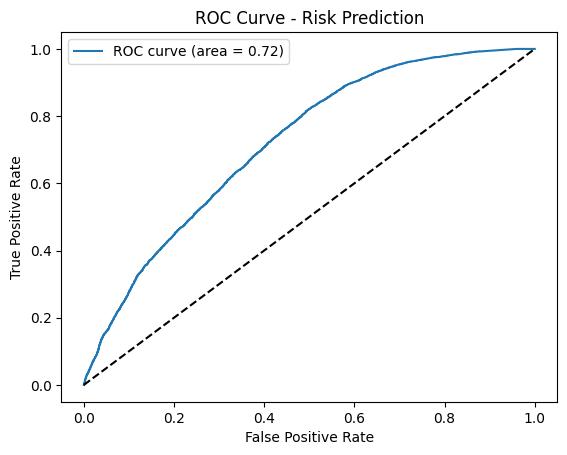

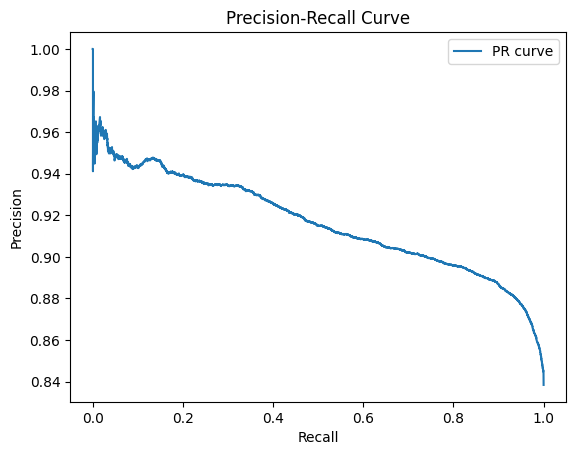

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

val_probs = F.softmax(val_out, dim=1).cpu().numpy()  # shape: (n_samples, 2)
y_prob = val_probs[:, 1]

# y_prob: predicted risk probabilities (not just hard class!) for the "Risk" class
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Risk Prediction')
plt.legend()
plt.show()

# PR Curve
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure()
plt.plot(recall, precision, label='PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


Epoch 1, Train Loss: 0.3470, Train Acc: 0.8802, Val Loss: 0.3873, Val Acc: 0.8526
Epoch 2, Train Loss: 0.3460, Train Acc: 0.8804, Val Loss: 0.3843, Val Acc: 0.8530
Epoch 3, Train Loss: 0.3450, Train Acc: 0.8804, Val Loss: 0.3827, Val Acc: 0.8531
Epoch 4, Train Loss: 0.3443, Train Acc: 0.8808, Val Loss: 0.3824, Val Acc: 0.8526
Epoch 5, Train Loss: 0.3436, Train Acc: 0.8808, Val Loss: 0.3832, Val Acc: 0.8520
Epoch 6, Train Loss: 0.3431, Train Acc: 0.8804, Val Loss: 0.3848, Val Acc: 0.8512
Epoch 7, Train Loss: 0.3427, Train Acc: 0.8802, Val Loss: 0.3867, Val Acc: 0.8494
Epoch 8, Train Loss: 0.3423, Train Acc: 0.8804, Val Loss: 0.3887, Val Acc: 0.8483
Epoch 9, Train Loss: 0.3419, Train Acc: 0.8809, Val Loss: 0.3905, Val Acc: 0.8477
Epoch 10, Train Loss: 0.3414, Train Acc: 0.8806, Val Loss: 0.3919, Val Acc: 0.8469
Epoch 11, Train Loss: 0.3409, Train Acc: 0.8801, Val Loss: 0.3927, Val Acc: 0.8464
Epoch 12, Train Loss: 0.3401, Train Acc: 0.8800, Val Loss: 0.3929, Val Acc: 0.8459
Epoch 13, Tra

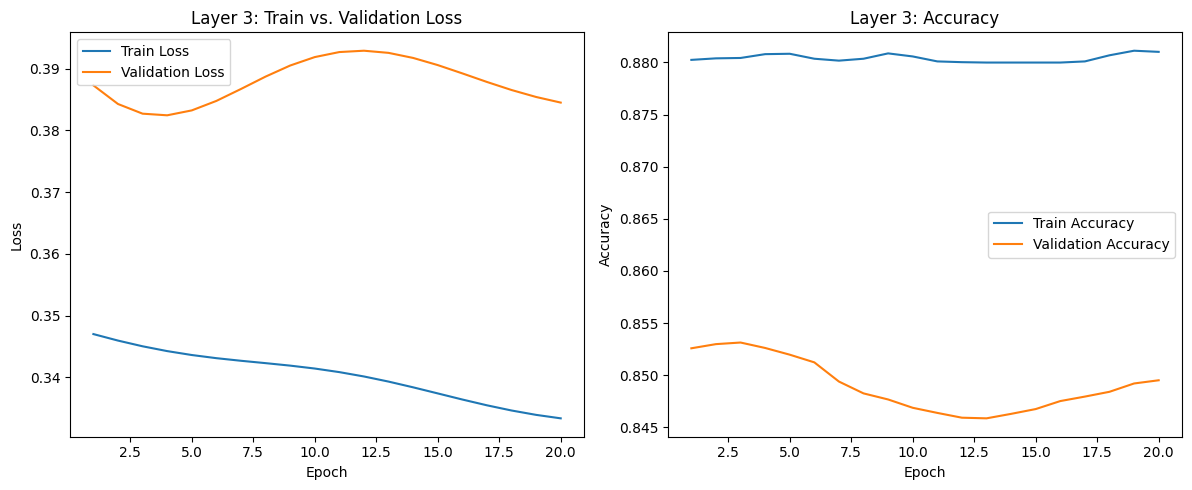

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

num_epochs = 20
for epoch in range(num_epochs):
    # TRAINING
    model.train()
    optimizer.zero_grad()
    out = model(data_train.x.to(device), data_train.edge_index.to(device))
    loss = F.cross_entropy(out, data_train.y.to(device))
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())

    train_pred = out.argmax(dim=1)
    train_acc = (train_pred == data_train.y.to(device)).sum().item() / len(data_train.y)
    train_acc_history.append(train_acc)

    # VALIDATION
    model.eval()
    with torch.no_grad():
        val_out = model(data_val.x.to(device), data_val.edge_index.to(device))
        val_loss = F.cross_entropy(val_out, data_val.y.to(device))
        val_pred = val_out.argmax(dim=1)
        val_acc = (val_pred == data_val.y.to(device)).sum().item() / len(data_val.y)
    val_loss_history.append(val_loss.item())
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}, "
          f"Train Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")

# PLOT
epochs = range(1, num_epochs+1)
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(epochs, train_loss_history, label="Train Loss")
plt.plot(epochs, val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Layer 3: Train vs. Validation Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(epochs, train_acc_history, label="Train Accuracy")
plt.plot(epochs, val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Layer 3: Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
